In [2]:
# Import  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,  RandomForestRegressor
from sklearn.metrics import accuracy_score,  confusion_matrix, mean_squared_error,  r2_score
from sklearn.preprocessing import LabelEncoder

In [4]:
# Load the dataset
df = pd.read_csv("amazon_products_sales_data_cleaned.csv")
print("\n First five rows of the Dataset:")
print(df.head())


 First five rows of the Dataset:
                                       product_title  product_rating  \
0  BOYA BOYALINK 2 Wireless Lavalier Microphone f...             4.6   
1  LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...             4.3   
2  DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...             4.6   
3  Apple AirPods Pro 2 Wireless Earbuds, Active N...             4.6   
4  Apple AirTag 4 Pack. Keep Track of and find Yo...             4.8   

   total_reviews  purchased_last_month  discounted_price  original_price  \
0          375.0                 300.0             89.68          159.00   
1         2457.0                6000.0              9.99           15.99   
2         3044.0                2000.0            314.00          349.00   
3        35882.0               10000.0            162.24          162.24   
4        28988.0               10000.0             72.74           72.74   

  is_best_seller is_sponsored             has_coupon buy_box_availability  \

In [6]:
# summary
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [8]:
print(df.describe())

       product_rating  total_reviews  purchased_last_month  discounted_price  \
count    41651.000000   41651.000000          32164.000000      40613.000000   
mean         4.399431    3087.106000           1293.665278        243.227289   
std          0.386997   13030.460133           6318.323574        473.351545   
min          1.000000       1.000000             50.000000          2.160000   
25%          4.200000      82.000000            100.000000         29.690000   
50%          4.500000     343.000000            200.000000         84.990000   
75%          4.700000    1886.000000            400.000000        224.000000   
max          5.000000  865598.000000         100000.000000       5449.000000   

       original_price  discount_percentage  
count    40613.000000         40613.000000  
mean       257.611107             6.547151  
std        496.633495            12.744715  
min          2.160000             0.000000  
25%         32.990000             0.000000  
50%      

In [10]:
# Encode categorial variables
if 'product_catehory' in df.columns:
    df['product_category'] = LabelEncoder().fit_transform(df['product_category'])

In [12]:
# Handle missing values
df = df.dropna()

In [14]:
# Define Features and targets
X = df[['original_price', 'product_rating', 'discount_percentage']]
y = df['total_reviews']

# train--test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [16]:
# Build Random Forest Model

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [18]:
## Evaluate Model
y_pred = rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test,  y_pred))
print("\nAccuracy Score:\n", accuracy_score(y_test,  y_pred))

Confusion Matrix:
 [[0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 4]]

Accuracy Score:
 0.7405405405405405


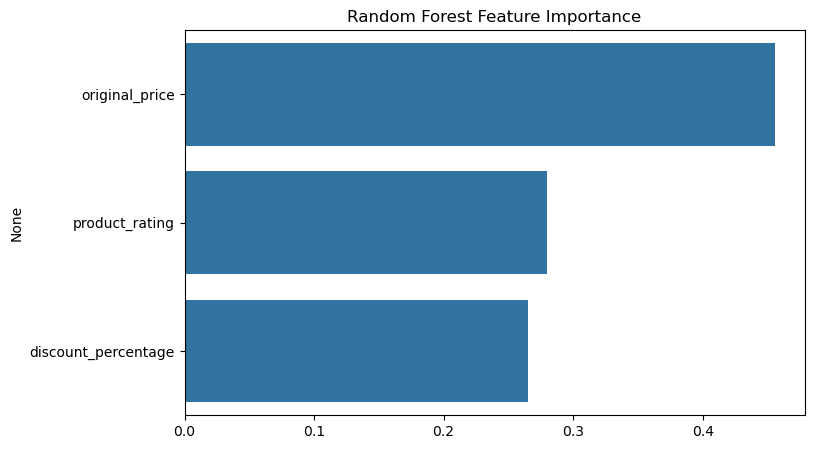

In [20]:
# Feature Importance
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances,  y=features)
plt.title("Random Forest Feature Importance")
plt.show()